# 表示的困境：OneHot编码与模型局限

通过本次任务，你将学会如何使用 OneHot 表示文本，提高情感分析模型的能力。

## 任务背景

无人奶茶店业务仍在持续扩张，你每天收到的顾客评价数量呈指数级增长。在上一章的实践中，你成功构建了一个基于字符 ID 序列的情感分类流程，迈出了自然语言处理的第一步。然而，这个模型在历史数据上表现尚可，但在面对未曾见过的评价时，其判断力急剧下降，陷入了严重的过拟合。

经过深入分析，你发现问题根源在于文本的表示方式。采用“字符 ID 索引”的表示方法，会存在很大的数，这种大数对模型来说非常不稳定，当它位置稍有变化就会引起模型的大幅震荡。

那么如何解决这个问题呢？

## 最少必要知识

- OneHot 编码

## 任务鸟瞰

### 任务分析

本次任务是通过改进语言的表示形式，解决使用 Token ID 带来的大数问题，提高模型性能。

![任务鸟瞰](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204185823.png)

自然语言处理表示文本最经典的方法：**One-Hot 编码**。与字符索引的任意整数不同，OneHot 向量将每个字符表示为一个稀疏的二值向量，其维度等于整个字符集的大小。

假设词表为 `{'动': 0, '手': 1, '学': 2, '大': 3, '模': 4, '型': 5}`，OneHot 编码会将每个字符表示为一个长度为6（词表大小）的二值向量。在该向量中，仅在与字符索引对应的位置上为1，其余位置均为0，所以才将这种方法称之为独热编码。

具体编码结果如下表所示：
```{list-table} 
:header-rows: 1

* - 字符
  - 索引
  - One-Hot编码向量
* - 动
  - 0
  - `[**1**, 0, 0, 0, 0, 0]`
* - 手
  - 1
  - `[0, **1**, 0, 0, 0, 0]`
* - 学
  - 2
  - `[0, 0, **1**, 0, 0, 0]`
* - 大
  - 3
  - `[0, 0, 0, **1**, 0, 0]`
* - 模
  - 4
  - `[0, 0, 0, 0, **1**, 0]`
* - 型
  - 5
  - `[0, 0, 0, 0, 0, **1**]`
```

OneHot 编码完美的解决了上一章存在的大数问题，下面我们使用 OneHot 编码来提高模型性能。

### 模型结构

本次的改进只是将文本表示方式由字符索引变为 OneHot 编码，模型的结构不变。

![情感分析模型结构](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260317072009.png)

依然沿用 NLP 任务的通用开发流程组织本章内容：定义分词器、数据准备、模型定义、模型训练与模型评估。在正式开始之前，先配置环境，避免因为环境不同而导致程序不能复现。

## 环境配置

### 安装依赖

In [ ]:
!pip install --upgrade dsxllm -i https://pypi.org/simple

### 环境版本

In [2]:
from dsxllm.util import show_version

show_version()

本书愿景：
+------+--------------------------------------------------------+
| Info |                  《动手学大语言模型》                  |
+------+--------------------------------------------------------+
| 作者 |                       吾辈亦有感                       |
| 哔站 |      https://space.bilibili.com/3546632320715420       |
| 定位 | 基于'从零构建'的理念，用实战帮助程序员快速入门大模型。 |
| 愿景 | 若让你的AI学习之路走的更容易一点，我将倍感荣幸！祝好😄 |
+------+--------------------------------------------------------+
环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.10.0    |         2.6.1          |
+-------------+--------------+------------------------+


## 自定义分词器

数据的格式和分词器代码与第 5 章内容一致，此处不再重复说明。

### 自定义分词器的代码实现

In [3]:
class SimpleTokenizer:
    def __init__(self):
        """
        初始化简单分词器
        """
        # 特殊token
        self.pad_token = '[PAD]'
        self.unk_token = '[UNK]'

        # 特殊token ID
        self.pad_token_id = 0
        self.unk_token_id = 1

        # 构建词汇表
        self.vocab = {
            self.pad_token: self.pad_token_id,
            self.unk_token: self.unk_token_id,
        }

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}

        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def build_vocab(self, texts):
        """
        根据文本构建词汇表
        """
        for text in texts:
            words = list(text)  # 将每个汉字作为独立token

            for word in words:
                if word not in self.vocab:
                    self.vocab[word] = self.vocab_size
                    self.ids_to_tokens[self.vocab_size] = word
                    self.vocab_size += 1

    def build_vocab_from_file(self, file_path):
        """
        从文件中构建词汇表
        """
        texts = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                texts.append(line.strip())

        self.build_vocab(texts)

    def encode(self, text):
        """
        将文本编码为token ids
        """
        tokens = list(text)

        # 转换为IDs
        token_ids = []
        for token in tokens:
            if token in self.vocab:
                token_ids.append(self.vocab[token])
            else:
                token_ids.append(self.unk_token_id)

        return token_ids

    def decode(self, token_ids, skip_special_tokens=True):
        """
        将token ids解码为文本
        """
        tokens = []
        for token_id in token_ids:
            if token_id in self.ids_to_tokens:
                token = self.ids_to_tokens[token_id]

                # 过滤特殊token
                if skip_special_tokens:
                    if token not in [self.pad_token, self.unk_token]:
                        tokens.append(token)
                else:
                    tokens.append(token)
        return ''.join(tokens)

    def pad_sequences(self, sequences, max_length):
        """
        对序列进行填充或截断
        """
        padded_sequences = []

        for seq in sequences:
            if len(seq) > max_length:
                # 截断
                padded_seq = seq[:max_length]
            else:
                # 填充
                pad_length = max_length - len(seq)
                padded_seq = seq + [self.pad_token_id] * pad_length

            padded_sequences.append(padded_seq)

        return padded_sequences

    def __call__(self, texts, max_length=128):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        for text in texts:
            token_ids = self.encode(text)
            all_token_ids.append(token_ids)

        # 填充或截断到统一长度
        padded_token_ids = self.pad_sequences(all_token_ids, max_length)

        if is_single_text:
            padded_token_ids = padded_token_ids[0]

        return padded_token_ids

### 创建自定义分词器的实例

In [4]:
# 使用 print_table 展示结果
from dsxllm.util import print_table

# 示例文本
sample_texts = [
    "动手学大模型",
    "吾辈亦有感"
]

# 创建分词器实例
tokenizer = SimpleTokenizer()

# 构建词汇表
tokenizer.build_vocab(sample_texts)

# 构建词汇表信息表格
vocab_info = [["Vocabulary Size", tokenizer.vocab_size]]
print_table("分词器信息", ["项目", "值"], vocab_info)

# 显示词表
print_table("字符到ID的映射表", field_names=["Token", "Token ID"], data=[
    [token, tokenizer.vocab[token]] for token in tokenizer.vocab])

分词器信息：
+-----------------+----+
|       项目      | 值 |
+-----------------+----+
| Vocabulary Size | 13 |
+-----------------+----+
字符到ID的映射表：
+-------+----------+
| Token | Token ID |
+-------+----------+
| [PAD] |    0     |
| [UNK] |    1     |
|   动  |    2     |
|   手  |    3     |
|   学  |    4     |
|   大  |    5     |
|   模  |    6     |
|   型  |    7     |
|   吾  |    8     |
|   辈  |    9     |
|   亦  |    10    |
|   有  |    11    |
|   感  |    12    |
+-------+----------+


## 准备数据

### 数据集下载

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('dataset'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">数据集下载</h4>
                <p class="card-text">
                    如果你想要亲自动手复现运行结果，可以点击此链接下载相关数据集。
                </p>
            </div>
        </div>
    </div>
</a>
```

### 自定义数据转化器
自定义一个数据预处理转换器 `TextTransform` 类，使用分词器将给定的文本字符串转换为 Token ID 序列后，再将其转化为 One-Hot 编码张量。

![OneHot 数据处理](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260205092021.png)

#### 数据转化器的代码实现

In [5]:
import torch
import torch.nn.functional as F


class TextTransform:
    def __init__(self, tokenizer, max_length=30, vocab_size=None):
        self.tokenizer = tokenizer
        self.max_length = max_length
        # 需要知道词汇表大小来创建 one-hot 向量
        self.vocab_size = vocab_size or tokenizer.vocab_size

    def __call__(self, text):
        # 使用 tokenizer 对文本进行编码，并自动完成截断与填充
        input_ids = self.tokenizer(
            text,
            max_length=self.max_length,  # 最大序列长度
        )

        # 将 input_ids 转换为 one-hot 向量
        # 注意：这里假设 input_ids 是一个列表或者一维张量
        # 如果 input_ids 不是 tensor，则转换为 tensor
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.long)

        # 🌟改进点：转换为 one-hot 向量
        one_hot = F.one_hot(input_ids, num_classes=self.vocab_size).float()

        return one_hot

在使用 `Tokenizer` 将文本编码成 ID 序列后，使用 PyTorch 的 `one_hot()` 将得到的整数 ID 序列转换为一个稀疏的二值向量序列。每个 ID 被扩展为一个长度等于 `vocab_size` 的向量，其中仅在对应 ID 索引的位置上值为 1，其余位置为 0。最后，将数据类型转换为 `float` 以适配神经网络的输入要求。

#### 数据转化器的使用示例

In [6]:
# 设置最大序列长度
max_length = 10

# 示例文本
sample_text = "动手学大语言模型"

# 创建 TextTransform 实例，用于将文本转换为 One-Hot 编码
text_transform = TextTransform(tokenizer, max_length=max_length)

# 使用 tokenizer 对示例文本进行编码，得到 Token ID 序列
input_ids = tokenizer(sample_text, max_length=max_length)

# 使用 text_transform 将示例文本转换为 One-Hot 编码张量
encoded_token_ids = text_transform(sample_text)

# 打印词表大小
print("词表大小：", tokenizer.vocab_size)

# 打印 tokenizer 编码后的 Token ID 序列
print("Tokenizer Encode Input IDs:", input_ids)

# 打印 tokenizer 解码后的文本（包含特殊 Token）
print("Tokenizer Decode Input:", tokenizer.decode(input_ids, skip_special_tokens=False))

# 打印应用 One-Hot 编码后张量的形状
print("OneHot Encoded Shape:", encoded_token_ids.shape)

# 打印应用 One-Hot 编码后张量的具体内容
print("OneHot Encoded:", encoded_token_ids)

词表大小： 13
Tokenizer Encode Input IDs: [2, 3, 4, 5, 1, 1, 6, 7, 0, 0]
Tokenizer Decode Input: 动手学大[UNK][UNK]模型[PAD][PAD]
OneHot Encoded Shape: torch.Size([10, 13])
OneHot Encoded: tensor([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])


从结果中可以看到，示例文本编码后的数据形状为 `[10, 13]`。
- **第一个维度 `10`**：代表处理后的序列长度。这是在初始化 `TextTransform` 时设定的 `max_length` 参数。无论输入文本多长，`TextTransform` 都会通过分词器的 `pad_sequences` 方法将其统一处理（截断或填充）为长度为 10 的序列。
- **第二个维度 `13`**：代表词汇表的大小 (`vocab_size`)。这是根据分词器 `tokenizer` 构建的词表长度自动确定的。`TextTransform` 内部使用 `F.one_hot` 函数，将每个字符的 ID 索引转换为一个长度为 `vocab_size` 的 OneHot 向量。

### 自定义文本分类数据集

#### 文本分类数据集的代码实现
这部分代码与第5章内容一致，此处不再重复说明

In [7]:
import torch
from torch.utils.data import Dataset


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, transform):
        self.texts = texts
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        input_ids = self.transform(text)

        return {
            "input_ids": input_ids,
            "labels": torch.tensor(label, dtype=torch.long)
        }

    @classmethod
    def from_file(cls, file_path, transform):
        """
        从txt文件加载数据集
        txt格式应包含标签和文本，使用制表符分隔
        """

        texts = []
        labels = []

        # 读取txt文件
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    # 使用制表符分割
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        label = int(parts[0])  # 第一列是标签
                        text = '\t'.join(parts[1:])  # 剩余部分是文本（处理文本中可能包含制表符的情况）
                        texts.append(text)
                        labels.append(label)

        # 创建数据集实例
        return cls(texts, labels, transform)

#### 文本分类数据集的使用示例
创建文本分类数据集流程：
- `SimpleTokenizer()` 创建字符级分词器
- `build_vocab_from_file()` 从训练文件读取所有文本，构建包含所有出现字符的词汇表
- `TextTransform()` 创建转换器，将文本转换为固定长度的 One-Hot 编码
- `TextClassificationDataset.from_file()` 从文件加载带标签的数据集

In [8]:
# 导入 pprint 模块，用于美化打印数据结构
from pprint import pprint

# 定义数据文件路径
file_path = "./dataset/comments_train.txt"

# 1. 创建分词器实例
tokenizer = SimpleTokenizer()

# 2. 从文件中构建词汇表
tokenizer.build_vocab_from_file(file_path)

# 3. 创建数据转换器实例，设置最大序列长度为 10
transform = TextTransform(tokenizer, max_length=10)

# 4.从文件加载数据集，并应用转换器进行预处理
dataset = TextClassificationDataset.from_file(file_path, transform=transform)

# 打印前两个样本的 input_ids 形状
print("词表大小:", tokenizer.vocab_size)
print("input_ids shape:", dataset[:2]['input_ids'].shape)
pprint(dataset[:2])

词表大小: 1725
input_ids shape: torch.Size([2, 10, 1725])
{'input_ids': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]),
 'labels': tensor([1, 0])}


从结果中我们可以看到数据集中的数据符合我们的预期，`input_ids` 是一个 3 维张量，形状为`[2, 10, 1725]`，也可以写成 `[batch_size, max_length, vocab_size]`。这个三维张量的每个维度都有明确的含义：
- 第一个维度 `2`：代表批量大小（`batch_size`）。使用 `dataset[:2]` 切片的方式从数据集中只取了前两个样本。
- 第二个维度 `10`：代表序列长度（`max_length`）。在初始化 `TextTransform` 时通过参数 `max_length=10` 设定的。无论原始文本多长，`TextTransform` 都会调用分词器的 `pad_sequences` 方法，将所有文本统一处理（截断或填充）为长度为 10 的序列。
- 第三个维度 `1725`：代表词汇表大小（`vocab_size`）。这是由 `SimpleTokenizer` 从 `./dataset/comments_train.txt` 文件中构建的词汇表决定的。`TextTransform` 内部使用 `F.one_hot` 函数，将每个字符的 ID 索引转换为一个长度为 `vocab_size` 的 One-Hot 向量。词汇表大小为 1725 ，那么每个字符就被表示为一个长度为 1725 的向量，其中只有对应索引的位置是 1，其余位置都是 0。

### 自定义文本分类数据模组
#### 文本分类数据模组的代码实现
此部分代码和第5章一致，不再进行赘述。

In [9]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    def __init__(self, batch_size, transform, train_data_file, val_data_file="", test_data_file=""):
        super().__init__()

        # 训练、验证和测试数据文件路径
        self.train_data_file = train_data_file  # 训练数据文件路径
        self.val_data_file = val_data_file  # 验证数据文件路径（可选）
        self.test_data_file = test_data_file  # 测试数据文件路径（可选）

        # 数据集实例，初始为None，在setup方法中初始化
        self.test_dataset = None  # 测试数据集
        self.val_dataset = None  # 验证数据集
        self.train_dataset = None  # 训练数据集

        # 批次大小和数据转换器
        self.batch_size = batch_size  # 每个批次的样本数量
        self.transform = transform  # 数据转换器，用于预处理数据

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        # 此方法通常用于下载数据或进行一次性操作
        pass

    def setup(self, stage=None):
        # 根据阶段加载数据集
        # 加载训练数据集
        self.train_dataset = TextClassificationDataset.from_file(
            self.train_data_file,
            transform=self.transform
        )

        # 如果未提供验证数据文件，则使用训练数据集作为验证集
        if self.val_data_file == "":
            self.val_dataset = self.train_dataset
        else:
            # 否则加载指定的验证数据集
            self.val_dataset = TextClassificationDataset.from_file(
                self.val_data_file,
                transform=self.transform
            )

        # 如果未提供测试数据文件，则使用验证数据集作为测试集
        if self.test_data_file == "":
            self.test_dataset = self.val_dataset
        else:
            # 否则加载指定的测试数据集
            self.test_dataset = TextClassificationDataset.from_file(
                self.test_data_file,
                transform=self.transform
            )

    def train_dataloader(self):
        # 返回训练数据的DataLoader，启用shuffle以打乱数据顺序
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        # 返回验证数据的DataLoader，不打乱数据顺序
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        # 返回测试数据的DataLoader，不打乱数据顺序
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

#### 文本分类数据模组的使用示例

In [10]:
# 创建 DataModule 实例
max_length = 30
tokenizer = SimpleTokenizer()
tokenizer.build_vocab_from_file("./dataset/comments_train.txt")
transform = TextTransform(tokenizer, max_length=max_length)
text_datamodule = TextDataModule(batch_size=2, transform=transform, train_data_file="./dataset/comments_train.txt")

# 调用 setup 方法初始化数据集
text_datamodule.setup()

# 获取训练数据加载器
train_loader = text_datamodule.train_dataloader()

# 打印一个批次的数据
print("打印一个批次的数据：")
for batch in train_loader:
    pprint(batch, sort_dicts=False)
    print("-" * 20)
    print("input_ids shape: ", batch["input_ids"].shape)
    print("labels shape: ", batch["labels"].shape)
    break

打印一个批次的数据：
{'input_ids': tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]]]),
 'labels': tensor([0, 0])}
--------------------
input_ids shape:  torch.Size([2, 30, 1725])
labels shape:  torch.Size([2])


这部分代码和第5章相同，但其中每个批次的数据却大相径庭，每个批次的数据形状从 2 维升级到了 3 维。
具体区别如下：
```{list-table} 
:header-rows: 1

* - 特性
  - 使用 Token ID 表示字符
  - 使用 OneHot 向量表示字符
* - 表示本质
  - 整数索引
  - 稀疏二值向量
* - 单个字符表示
  - 一个标量
  - 一个向量
* - 输入形状
  - `[batch_size, max_length]`
  - `[batch_size, max_length, vocab_size]`
* - 优点
  - 存储和传输效率高，维度低。
  - 表示明确，消除了ID数值的任意性和大小带来的问题；
```

## 调整情感分析模型
随着文本表示从简单的 Token ID 升级为 One-Hot 向量，每个批次的输入数据形状也随之从二维 `[batch_size, max_length]` 升级到了三维 `[batch_size, max_length, vocab_size]`。这带来了一个新的挑战：我们原有的情感分析模型，是用于处理一维序列的简单前馈神经网络，该如何处理更高维度的输入呢？

最直观且自然的解决方案是进行**维度展平**（Flatten）。在模型的前向计算之前，我们将三维的输入张量 `input_ids` 重塑（`view`）成二维张量，具体变换过程为：`[batch_size, max_length, vocab_size] → [batch_size, max_length * vocab_size]`。

![OneHot向量展平](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260205102343.png)


### 情感分类模型的代码实现

在本项目中 `max_length=30`、`vocab_size=1725`，则每个样本将从 30 个 1725 维的向量，被展平为一个 51750 维的超长特征向量。相应地，模型的输入层维度从原先的 `max_length`（序列最大长度）急剧扩张为 `max_length * vocab_size`（序列长度与词汇表大小的乘积）。

模型的调整如下：

![参数量激增](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260205102409.png)

模型的网络结构没有变化，但是需要对输入进行展平操作。在 `training_step()`、`validation_step()` 和 `predict()` 中，将输入张量 `input_ids` 重塑为二维张量。完整代码如下：

In [11]:
import torch
import lightning as L
from torch import nn
import torch.nn.functional as F


class TextClassifier(L.LightningModule):
    def __init__(self, input_size=10, hidden_size=128, num_classes=2, learning_rate=0.01):
        super(TextClassifier, self).__init__()
        self.learning_rate = learning_rate

        # 定义网络层
        self.input_layer = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.hidden_layer = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.output_layer = nn.Linear(hidden_size, num_classes)

        # 存储每个训练步骤和训练循环的损失
        self.train_step_losses = []
        self.train_epoch_losses = []

        # 用于存储验证步骤的结果
        self.validation_step_outputs = []
        self.eval_accuracies = []

        # 示例输入
        self.example_input_array = torch.Tensor(32, input_size)

        # 标签id到标签的映射，用于预测解码
        self.label_map = None

    def forward(self, x):
        """前向传播"""
        out = self.input_layer(x)
        out = self.relu1(out)
        out = self.hidden_layer(out)
        out = self.relu2(out)
        out = self.output_layer(out)
        return out

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["input_ids"]
        # 🌟改进点：将输入数据从三维变为二维
        input_ids = input_ids.view(input_ids.shape[0], -1)
        labels = batch["labels"]

        # 前向传播
        outputs = self(input_ids)
        loss = F.cross_entropy(outputs, labels)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()

        # 记录日志
        self.log('train_loss', loss)
        self.log('train_acc', acc)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,
                "loss": avg_train_loss.item()  # 转换为 Python 数值
            })

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def validation_step(self, batch, batch_idx):
        """验证步骤"""
        input_ids = batch["input_ids"]

        # 🌟改进点：将输入数据从三维变为二维
        input_ids = input_ids.view(input_ids.shape[0], -1)
        target_ids = batch["labels"]

        # 前向传播
        outputs = self(input_ids)

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({'preds': preds, 'labels': target_ids})

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])
        all_labels = torch.cat([x['labels'] for x in self.validation_step_outputs])

        # 计算整体准确率
        val_overall_acc = (all_preds == all_labels).float().mean()

        # 记录整体准确率
        self.log('total_samples', len(all_labels))
        self.log('total_correct', (all_preds == all_labels).float().sum())
        self.log('val_overall_acc', val_overall_acc)

        # 将评估结果保存到 eval_accuracies 列表中
        self.eval_accuracies.append({
            "epoch": self.current_epoch,  # epoch编号
            "总样本数": len(all_labels),  # 验证集总样本数
            "正确样本数": int((all_preds == all_labels).float().sum().item()),  # 预测正确的样本数
            "准确率": round(val_overall_acc.item(), 4)  # 准确率
        })

        # 清空缓存
        self.validation_step_outputs.clear()

    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.eval_accuracies.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def setup_label_map(self, label_map=None):
        """根据数据集设置标签映射"""
        self.label_map = label_map

    def predict(self, input_ids):
        """
        对新数据进行预测
        
        Args:
            input_ids: 输入特征，可以是单个样本或批量样本
        Returns:
            predictions: 预测的标签索引
            decoded_predictions: 解码后的标签名称
            probabilities: 预测概率
        """
        # 确保模型处于评估模式
        self.eval()

        if isinstance(input_ids, list):
            input_ids = torch.stack(input_ids)  # 转换为张量

        # 确保输入是tensor格式
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.float32)

        # 🌟改进点：展平处理，与训练时保持一致
        if len(input_ids.shape) > 2:
            input_ids = input_ids.view(input_ids.shape[0], -1)

        # 预测
        with torch.no_grad():
            outputs = self(input_ids)
            predictions = torch.argmax(outputs, dim=1).tolist()
            probabilities = torch.softmax(outputs, dim=1).tolist()

        # 解码预测结果
        decoded_predictions = [self.label_map[pred] for pred in predictions]

        return predictions, decoded_predictions, probabilities

    def decode_labels(self, label_ids):
        """
        将标签ID解码为标签名称
        
        Args:
            label_ids: 标签ID列表
        Returns:
            decoded_labels: 解码后的标签名称列表
        """
        if isinstance(label_ids, torch.Tensor):
            label_ids = label_ids.tolist()
        return [self.label_map[label_id] for label_id in label_ids]

模型的前向传播需要二维输入。因此，在 `training_step`、`validation_step` 和 `predict` 方法中，一个核心步骤是调用 `input_ids.view(input_ids.shape[0], -1)`，将输入数据从 `[batch, seq_len, ...]` 的三维格式展平为 `[batch, -1]` 的二维格式。

### 情感分析模型的结构详情

使用 ModelSummary 生成模型详细的摘要信息。

In [12]:
# 导入 PyTorch Lightning 的模型摘要工具
from lightning.pytorch.utilities.model_summary import ModelSummary

# 获取词汇表大小
vocab_size = tokenizer.vocab_size

# 初始化 TextClassifier 模型，设置输入大小为词汇表大小乘以最大序列长度
model = TextClassifier(input_size=vocab_size * max_length, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

# 打印模型示例输入数组的形状
print(model.example_input_array.shape)

# 创建模型摘要对象，max_depth=-1 表示显示所有层级的详细信息
summary = ModelSummary(model, max_depth=-1)
print(summary)

torch.Size([32, 51750])
  | Name         | Type   | Params | Mode  | FLOPs  | In sizes    | Out sizes
-----------------------------------------------------------------------------------
0 | input_layer  | Linear | 6.6 M  | train | 423 M  | [32, 51750] | [32, 128]
1 | relu1        | ReLU   | 0      | train | 0      | [32, 128]   | [32, 128]
2 | hidden_layer | Linear | 16.5 K | train | 1.0 M  | [32, 128]   | [32, 128]
3 | relu2        | ReLU   | 0      | train | 0      | [32, 128]   | [32, 128]
4 | output_layer | Linear | 258    | train | 16.4 K | [32, 128]   | [32, 2]  
-----------------------------------------------------------------------------------
6.6 M     Trainable params
0         Non-trainable params
6.6 M     Total params
26.564    Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
425 M     Total Flops


初始化模型时，我们传入的 `input_size` 参数为 `vocab_size * max_length`（1725 × 30 = 51750）。从模型摘要信息中可以观察到，模型的参数量从上一章的`20.7K`（千参数）急剧膨胀到了 `6.6M`（百万参数）。

这种参数量的爆炸性增长源于 One-Hot 编码带来的维度扩展：
- 输入维度剧增：上一章使用字符 ID 序列时，每个样本的输入维度仅为 `max_length`（30）。而本章采用One-Hot编码后，每个字符被扩展为 `vocab_size`（1725）维的向量，整个样本的输入维度变为 `max_length × vocab_size`（51750）。
- 线性层参数计算：模型的第一层线性层 `nn.Linear(input_size, hidden_size)` 的参数数量为： $参数数量 = \text{input}_\text{size} \times \text{hidden}_\text{size} + \text{hidden}_\text{size}$代入具体数值： $51750 \times 128 + 128 \approx 6.6 M$这仅仅是第一层的参数量，还不包括后续隐藏层和输出层的参数。
- 对比分析：上一章模型的输入维度为 30，第一层线性层参数量仅为： $30 \times 128 + 128 \approx 4 K$相比之下，模型的参数量增加了约 `1650` 倍。

## 模型训练与评估

### 初始化模型和训练器

In [14]:
# 超参配置
max_length = 30
batch_size = 32

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer()
tokenizer.build_vocab_from_file("./dataset/comments_train.txt")

# 2️⃣ 创建数据转换器
transform = TextTransform(tokenizer, max_length=max_length)

# 3️⃣ 创建 DataModule 实例并设置
datamodule = TextDataModule(batch_size=batch_size, transform=transform, train_data_file="./dataset/comments_train.txt")

# 4️⃣ 创建模型实例：设置输入大小为词汇表大小乘以最大序列长度
model = TextClassifier(input_size=tokenizer.vocab_size * max_length, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

# 5️⃣ 创建PyTorch Lightning训练器，设置训练参数：
# - max_epochs=12: 最大训练轮数为12
# - log_every_n_steps=3: 每3个步骤记录一次日志
# - check_val_every_n_epoch=3: 每3个epoch进行一次验证
# - enable_progress_bar=False: 不显示进度条
trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0,
                    enable_progress_bar=False)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### 训练前评估

训练前评估为模型性能建立初始基准。

In [16]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1399.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.5128298997879028     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 1399.0,
  'val_overall_acc': 0.5128298997879028}]

在模型训练之前，模型预测的准确率为 `51.28%`，就是随机瞎猜的准确率，说明模型在训练前没有任何的预测能力。

### 训练模型

In [17]:
# 清除模型中存储的历史训练损失和评估指标数据，为新的训练做准备
model.clear_cache()

# 使用训练器在指定的数据模块上进行训练
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name         ┃ Type   ┃ Params ┃ Mode  ┃  FLOPs ┃    In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ input_layer  │ Linear │  6.6 M │ train │  423 M │ [32, 51750] │ [32, 128] │
│ 1 │ relu1        │ ReLU   │      0 │ train │      0 │   [32, 128] │ [32, 128] │
│ 2 │ hidden_layer │ Linear │ 16.5 K │ train │  1.0 M │   [32, 128] │ [32, 128] │
│ 3 │ relu2        │ ReLU   │      0 │ train │      0 │   [32, 128] │ [32, 128] │
│ 4 │ output_layer │ Linear │    258 │ train │ 16.4 K │   [32, 128] │   [32, 2] │
└───┴──────────────┴────────┴────────┴───────┴────────┴─────────────┴───────────┘

Trainable params: 6.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.6 M                                                                                                
Total estimated model params size (MB): 26                                                                         
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 425 M

`Trainer.fit` stopped: `max_epochs=12` reached.


#### 训练过程可视化

绘制训练过程中损失值的曲线，更直观地观察模型性能变化的趋势。

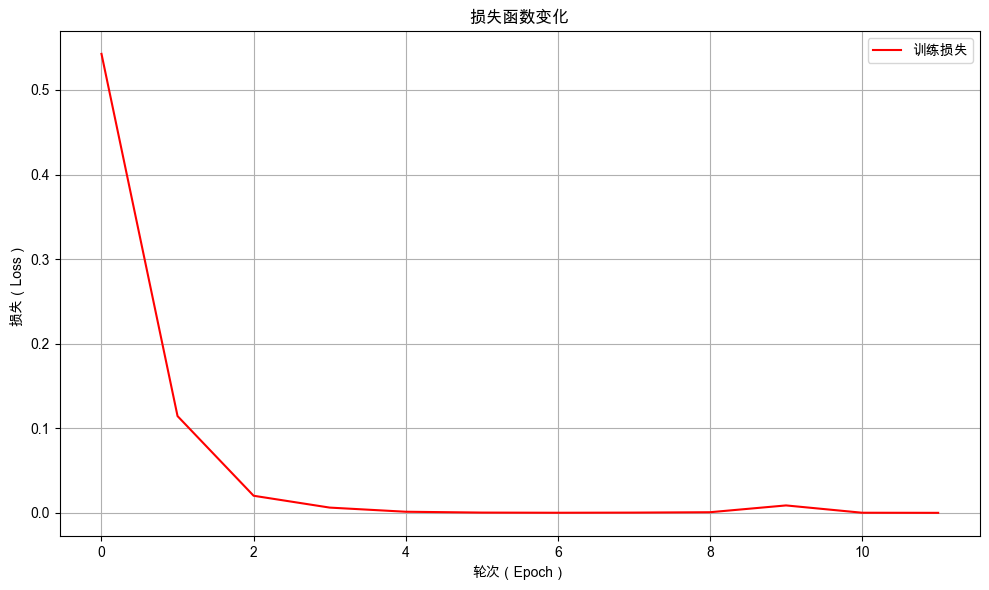

In [18]:
from dsxllm.util import plot_loss_curves

plot_loss_curves(model.train_epoch_losses)


从图中可以看出随着训练的进行，损失值不断下降，表示模型预测准确性不断提高。

#### 查看模型评估记录

查看训练过程中的评估结果，观察模型在验证集上的表现。

In [19]:
from dsxllm.util import to_dataframe

to_dataframe(model.eval_accuracies)


,epoch,总样本数,正确样本数,准确率
0,0,2728,2599,0.9527
1,1,2728,2713,0.9945
2,2,2728,2726,0.9993
3,3,2728,2727,0.9996
4,4,2728,2728,1.0000
5,5,2728,2728,1.0000
6,6,2728,2728,1.0000
7,7,2728,2727,0.9996
8,8,2728,2701,0.9901
9,9,2728,2728,1.0000


### 训练后评估

In [21]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2728.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │            1.0            │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0, 'total_correct': 2728.0, 'val_overall_acc': 1.0}]

从评估结果可以看出，模型在训练后的准确率达到了 `100%`，相较于训练前有了显著提升，这表明模型训练非常成功。

## 使用模型进行预测

在模型训练完成后，需要评估模型的泛化能力。我们准备了一组包含不同长度（短、中、长）且情感倾向明确的评论文本，并调用模型的 `predict` 方法进行推理预测，直观地观察模型在实际应用中的表现。

In [23]:
model.setup_label_map(label_map={0: "负面", 1: "正面"})

from dsxllm.util import print_classification_predictions

# 1. 准备需要预测的文本（长短不一）与对应的感情标签
new_texts = [
    # 短文本
    "非常好",
    "质量差",
    "推荐购买",
    "不建议买",

    # 中等长度文本
    "这个产品还不错",
    "物流速度太慢了",
    "性价比很高值得推荐",

    # 长文本
    "包装很精美，产品和描述一致，非常满意这次购物体验",
    "卖家服务态度不好，发货速度慢，产品质量也不如预期",
    "虽然价格有点贵，但是品质确实不错，使用效果很满意"
]

true_labels = [1, 0, 1, 0, 1, 0, 1, 1, 0, 1]

# 2. 使用与模型训练时相同的 transform 对文本进行处理
input_ids = []
for text in new_texts:
    # 使用训练时相同的 transform 
    transformed = transform(text)
    input_ids.append(transformed)

# 3. 使用模型进行预测
predictions, decoded_predictions, probabilities = model.predict(input_ids)

# 4. 输出预测结果
print_classification_predictions(new_texts, true_labels, predictions, probabilities, model.label_map)

🎯 分类预测结果 (准确率: 9/10 = 90.00%)：
+--------------------------------------------------+----------+----------+----------+------+
|                       输入                       | 真实标签 | 预测标签 | 最高概率 | 标记 |
+--------------------------------------------------+----------+----------+----------+------+
|                      非常好                      |   正面   |   正面   |  0.9996  |  ☑   |
|                      质量差                      |   负面   |   负面   |  0.9994  |  ☑   |
|                     推荐购买                     |   正面   |   正面   |  0.8977  |  ☑   |
|                     不建议买                     |   负面   |   负面   |  0.9956  |  ☑   |
|                  这个产品还不错                  |   正面   |   负面   |  0.9967  |  ☒   |
|                  物流速度太慢了                  |   负面   |   负面   |  0.9998  |  ☑   |
|                性价比很高值得推荐                |   正面   |   正面   |  0.9207  |  ☑   |
| 包装很精美，产品和描述一致，非常满意这次购物体验 |   正面   |   正面   |  0.9999  |  ☑   |
| 卖家服务态度不好，发货速度慢，产品质量也不如预期 |   负面   |   负面   |  0.9999 

本次预测取得了 `90%` 的准确率，相较于上一章仅 `50%` 的准确率，说明仅从 Token ID 序列升级为简单的 One-Hot 编码就实现了极大的性能提升。

为了进一步验证模型的泛化能力，我们使用一个独立的评估集重新评估模型。

## 泛化能力评估

In [25]:
from dsxllm.util import print_red

datamodule2 = TextDataModule(batch_size=batch_size, transform=transform,
                             train_data_file="./dataset/comments_train.txt",
                             val_data_file="./dataset/comments_val.txt")

print_red("在训练集上评估：")
trainer.validate(model=model, datamodule=datamodule)

print_red("在测试集上评估：")
trainer.validate(model=model, datamodule=datamodule2)

在训练集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2728.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │            1.0            │
└───────────────────────────┴───────────────────────────┘

在测试集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2274.0           │
│       total_samples       │          2789.0           │
│      val_overall_acc      │    0.8153460025787354     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2789.0,
  'total_correct': 2274.0,
  'val_overall_acc': 0.8153460025787354}]

从结果中我们可以看到，在评估集上模型的准确率也超过了 `80%`，说明这次模型训练的还不错。

## 本章小结

本章我们使用 One-Hot 编码将文本表示为向量，模型在评估集上的准确率从 `52.42%` 提升到了 `81.53%`。说明语言表示对模型理解能力至关重要，后续我们会探索更好的表示方法。但目前有一个更严重的挑战：传统的**前馈神经网络**要求固定长度的输入，序列长度的变化和 One-Hot 编码会带来维度灾难问题，使得模型参数量爆炸式增长。下一章，我们将引入循环神经网络（RNN）来解决这个问题。

## 答疑讨论

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('qa'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">答疑讨论</h4>
                <p class="card-text">
                    如果你有任何学习上的疑问，可以评论留言，和我一起讨论。我会抽空回复你的问题，也欢迎你回答其他人的问题。
                </p>
            </div>
        </div>
    </div>
</a>
```